In [27]:
#BASELINE MODEL - logistic regression model for predicting management strategy, 81% baseline accuracy.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


In [28]:
data = pd.read_excel("/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/synthetic_vestibular_schwannoma_data.xlsx")
data.tail()

,age_at_diagnosis,Sex,BMI,tumour_laterality,Scan 1: Volume,linear_regression_growth_rate_cm3,charlson_comorbidity_index,koos_grade_at_presentation,Management
4995,45,M,26.667706,R,6538.956,0.504685,0,4,Surgery
4996,27,F,21.561009,L,7037.702,0.494394,2,4,Surgery
4997,74,M,NaN,L,7297.534,0.430498,4,3,SRS
4998,67,F,25.622936,L,0.000,NaN,2,1,Surveillance
4999,66,F,26.097113,R,11921.273,1.303475,2,4,Surgery


In [4]:
X = data.drop(columns=["Management"])
y = data["Management"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#BASELINE PIPELINE
numeric_cols = ["BMI", "Scan 1: Volume", "linear_regression_growth_rate_cm3", "charlson_comorbidity_index", "age_at_diagnosis"]
categorical_cols = ["Sex", "koos_grade_at_presentation", "tumour_laterality"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

# pipeline = Pipeline([
  #  ("preprocessor", preprocessor),
   # ("model") #ADD MODELL PARAMETERS HERE
#])

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [15]:
#SVM
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
    ))
])

svm_cv_results = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("SVM Trial Run")
print("Mean CV accuracy:", svm_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", svm_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", svm_cv_results["test_f1_macro"].mean())


SVM Trial Run
Mean CV accuracy: 0.8110000000000002
Mean CV balanced accuracy: 0.8169035521544739
Mean CV macro F1: 0.8178349608781733


In [16]:
#Random Forrest
RF_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
    ))
])

RF_cv_results = cross_validate(
    RF_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("RF Trial Run")
print("Mean CV accuracy:", RF_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", RF_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", RF_cv_results["test_f1_macro"].mean())


RF Trial Run
Mean CV accuracy: 0.81875
Mean CV balanced accuracy: 0.8248532000463105
Mean CV macro F1: 0.8256864442091507


In [23]:
#K Nearest Neighbour

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=10
    ))
])

knn_cv_results = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("KNN Trial Run")
print("Mean CV accuracy:", knn_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", knn_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", knn_cv_results["test_f1_macro"].mean())


KNN Trial Run
Mean CV accuracy: 0.7939999999999999
Mean CV balanced accuracy: 0.7991399189931917
Mean CV macro F1: 0.8008264356985307


In [33]:
#XGBoost

# Encode target labels as integers as wont work otherwise for xgb
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

XGB_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

XGB_cv_results = cross_validate(
    XGB_pipeline,
    X_train,
    y_train_encoded,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("XGBoost Trial Run")
print("Mean CV accuracy:", XGB_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", XGB_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", XGB_cv_results["test_f1_macro"].mean())


XGBoost Trial Run
Mean CV accuracy: 0.80525
Mean CV balanced accuracy: 0.8111810167733976
Mean CV macro F1: 0.8129859122659646


In [32]:
#LogReg

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000
    ))
])

log_cv_results = cross_validate(
    log_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("LogReg Trial Run")
print("Mean CV accuracy:", log_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", log_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", log_cv_results["test_f1_macro"].mean())


LogReg Trial Run
Mean CV accuracy: 0.8092499999999999
Mean CV balanced accuracy: 0.8144320391474633
Mean CV macro F1: 0.8175291976836074


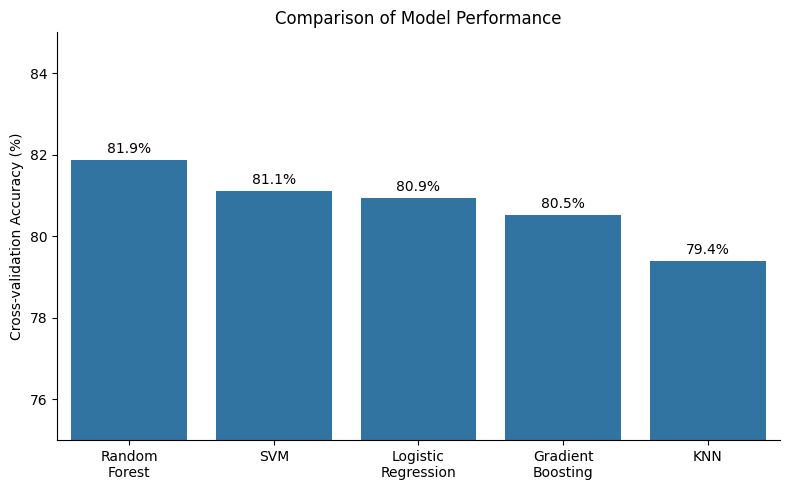

In [ ]:
# Mean CV accuracies (convert to percentages)
results = pd.DataFrame({
    "Model": [
        "Logistic\nRegression",
        "SVM",
        "Random\nForest",
        "KNN",
        "Gradient\nBoosting"
    ],
    "Accuracy": [
        log_cv_results["test_accuracy"].mean() * 100,
        svm_cv_results["test_accuracy"].mean() * 100,
        RF_cv_results["test_accuracy"].mean() * 100,
        knn_cv_results["test_accuracy"].mean() * 100,
        XGB_cv_results["test_accuracy"].mean() * 100
    ]
})

# Sort from best to worst
results = results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

# Add accuracy labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(75, 85)
plt.ylabel("Cross-validation Accuracy (%)")
plt.xlabel("")
plt.title("Comparison of Model Performance")
sns.despine()
plt.tight_layout()
plt.show()